# 

In [1]:
import os
import sys
import numpy as np
import swyft
import matplotlib.pyplot as plt
import copy
sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')

In [2]:
main_dir_name = "ALPs_with_SWYFT"
main_dir = os.getcwd().split(main_dir_name)[0]+main_dir_name+"/"
thesis_figs_dir = main_dir+"thesis_figures/"
irf_dir = main_dir+"IRFs/"
scripts_dir = main_dir+"analysis_scripts/ALP_sim/" # The directory where ALP_quick_sim.py is placed. Can be empty if it's in same folder as notebook.

In [3]:
irf_file = irf_dir+"CTA/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits"    # The path to the IRF_file (relative to this notebook)

In [4]:
if scripts_dir : sys.path.append(scripts_dir ) 
from ALP_quick_sim import ALP_sim

In [5]:
A = ALP_sim(set_null=False,set_obs=False)

In [6]:
A.configure_obs(
    signal = True,
    edisp = True,
    bkg = True,
    emin = 1e1,
    emax = 1e4,
    nbins = 40, #90
    nbins_etrue = 180,
    pointing = [150.58,-13.26],
    livetime=1,
    irf_file = irf_file,
    geom = 'gamma',    
)

A.configure_model(
    model = "",
    noise = "poisson",
    params = [0,0],
    log_params = [0,0],
    null_params = [0,0],  # should have been called 'standard_params', oh well...
    signal = True,
    bkg = True,
    logcounts = False,
    residuals = False,
    floor = None,
    floor_obs = None,
    ALP_seed = 0,
    noise_seed = 0,        # Makes sure the noise always turns out the same
)

A.configure_plot(
    xmin = None,
    xmax = None,
    ymin = None,
    ymax = None,
    logx = True,
    logy = True,
    legend = True,
    dnde = False,
)

/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim/ALP_quick_sim.py:476: UserWarning: The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal
  warnings.warn("The number of model parameters, log-indicators, null-hypothesis parameters, parameter names and parameter units are not equal")


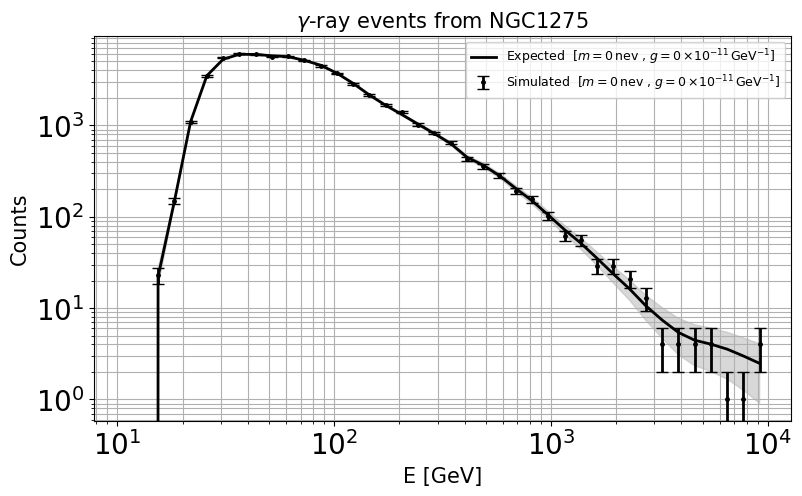

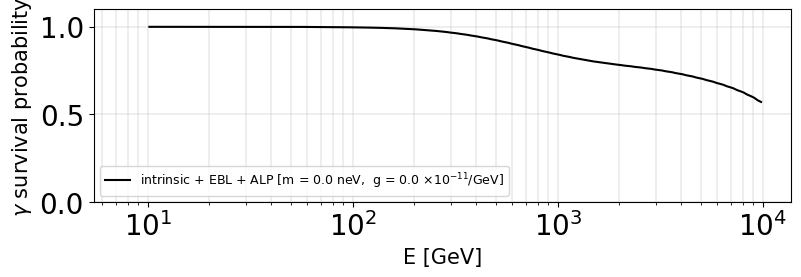

In [7]:
# A simple test 
A.compute_case(
    new_fig = True,
    new_counts = True,
    null = False,
    plot_obs = True,
    plot_exp = True,
    plot_survival = True,
    errorbands = True,
    errors = True,
    linestyle = "-",
    linestyle_obs = "-", 
    label_exp = True,
    label_obs = True,
    label_survival = True,
    transparency = 0,
    axes = None,
    axes_survival = None,
)

In [8]:
# Seed for B-field configurations, and [m,g] to be reused for several plots
demo_ALP_seed = 0
demo_params = [50,1]

# General arguments to compute_case(), to be re-used in most cases
general_arguments = dict(
    new_fig = False,
    new_counts = True,
    null = False,
    plot_obs = True,
    plot_exp = True,
    plot_survival = False,
    errorbands = True,
    errors = True,
    linestyle = "-",
    linestyle_obs = "-", 
    label_exp = True,
    label_obs = True,
    label_survival = True,
    transparency = 0,
    axes = None,
    axes_survival = None,
    color = 'r',
)

# Arguments to compute_case() to replace some of the general arguments when plotting the standard hypothesis
standard_hypothesis_arguments = dict(
    new_fig=True,
    null=True,
    plot_obs=False,
    color='k',
)

# General arguments to be used for plotting the photon survival probability
pgg_arguments = dict(
    new_fig = False,
    new_counts = True,
    null = False,
    plot_obs = False,
    plot_exp = False,
    plot_survival = True,
    errorbands = True,
    errors = True,
    linestyle = "-", 
    label_survival = True,
    transparency = 0,
    axes_survival = None,
    color = 'r',
)

Generating new null-hypothesis... done.


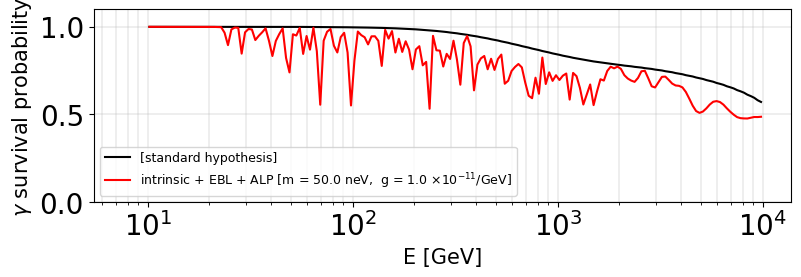

In [9]:
# Plot the photon survival probability
A.compute_case(**{**pgg_arguments,
    'new_fig':True,
    'null':True,
    'color':'k',
})

A.configure_model(ALP_seed=demo_ALP_seed, params = demo_params) 
A.compute_case(**{**pgg_arguments})

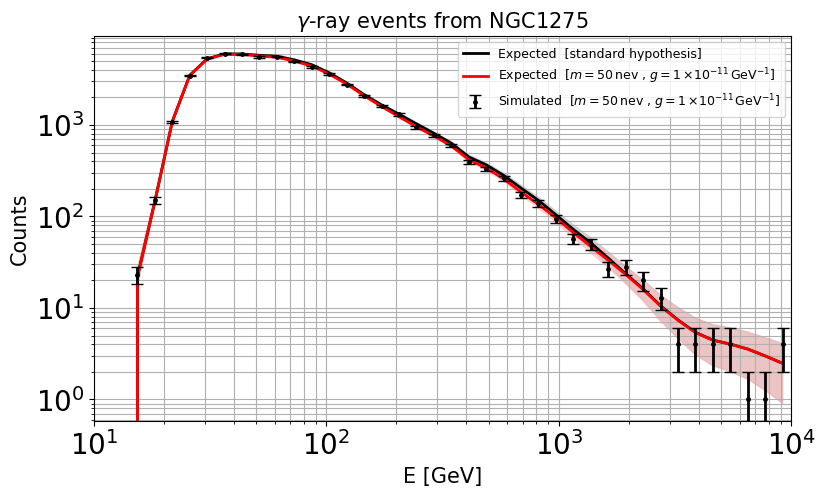

In [10]:
A.configure_plot(logy=True, xmin=1e1, xmax=1e4, ymin=None, ymax=None, legend_loc='upper right')

# Without ALPs, only expectations, not observations.
A.configure_model(params = [0,0], residuals=False, logcounts=False)
A.compute_case(**{**general_arguments,**standard_hypothesis_arguments})

# With ALPs, observations included.
A.configure_model(ALP_seed=demo_ALP_seed, params = demo_params)   
A.compute_case(**general_arguments)

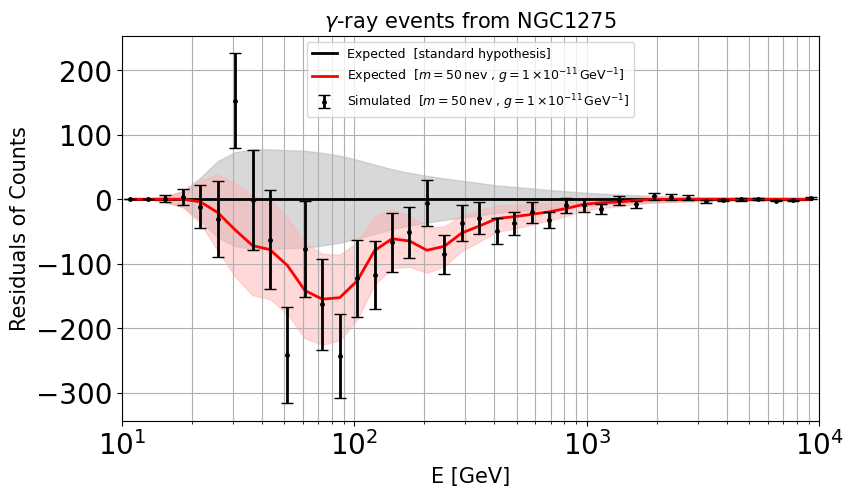

In [11]:
A.configure_plot(logy=False, xmin=1e1, xmax=1e4, ymin=None, ymax=None, legend_loc='upper center')
A.configure_model(residuals=True, logcounts=False)

# Without ALPs, only expectations, not observations.
A.configure_model(params = [0,0])
A.compute_case(**{**general_arguments,**standard_hypothesis_arguments})

# With ALPs, observations included.
A.configure_model(ALP_seed=demo_ALP_seed, params = demo_params)   
A.compute_case(**general_arguments)

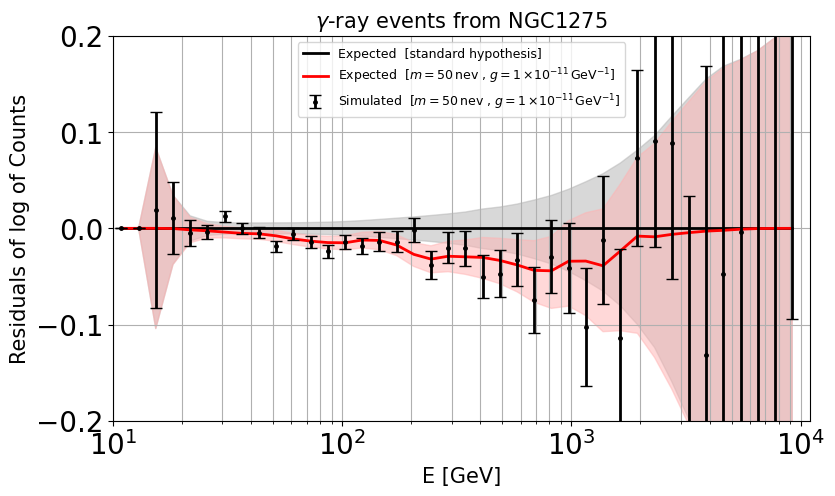

In [13]:
A.configure_plot(logy=False, xmin=1e1, xmax=1.1e4, ymin=-0.2, ymax=0.2, legend_loc='upper center')
A.configure_model(residuals=True, logcounts=True)

# Without ALPs, only expectations, not observations.
A.configure_model(params = [0,0])
A.compute_case(**{**general_arguments,**standard_hypothesis_arguments})

# With ALPs, observations included.
A.configure_model(ALP_seed=demo_ALP_seed, params = demo_params)   
A.compute_case(**general_arguments)

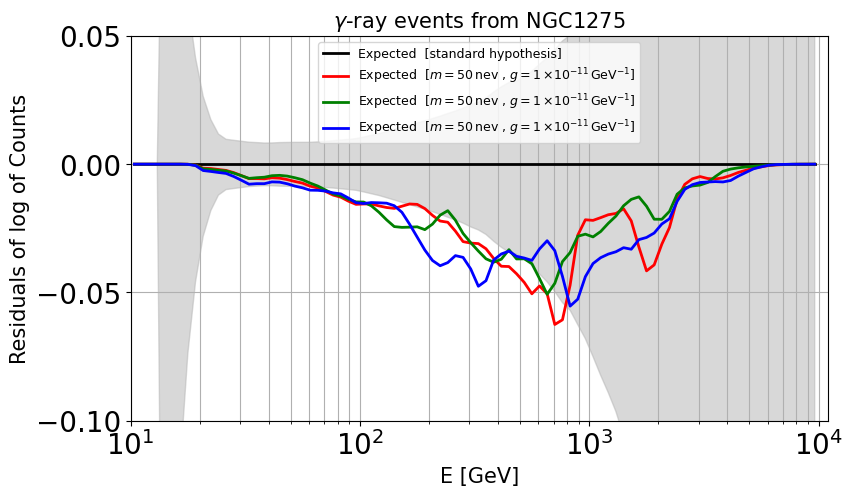

In [23]:
# Plot expected signals for different random B-field configurations

A.configure_plot(logy=False, xmin=1e1, xmax=1.1e4, ymin=-0.1, ymax=0.05, legend_loc='upper center')

A.configure_obs(nbins=90)
A.configure_model(residuals=True, logcounts=True, ALP_seed=None,params = demo_params)

# Without ALPs, only expectations, not observations.
A.compute_case(**{**general_arguments,**standard_hypothesis_arguments})

# With ALPs, observations included.
for color in ['r','g','b']:
    A.compute_case(**{**general_arguments,
        'errorbands':False,
        'plot_obs':False,
        'color':color,                 
    })